# Homework 3.4

## Setup from Lab 3.2.1

In [2]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from torch.utils.data import Dataset, DataLoader, TensorDataset
from torchvision import datasets, transforms

device = 'cpu'
torch.manual_seed(42)
np.random.seed(42)
if torch.cuda.is_available():
    device = 'cuda'
    torch.cuda.manual_seed(42)

print(f'Using device: {device}')

Using device: cuda


---
# Task 3.4.1

## Load and plot the dataset — from 3.2.1

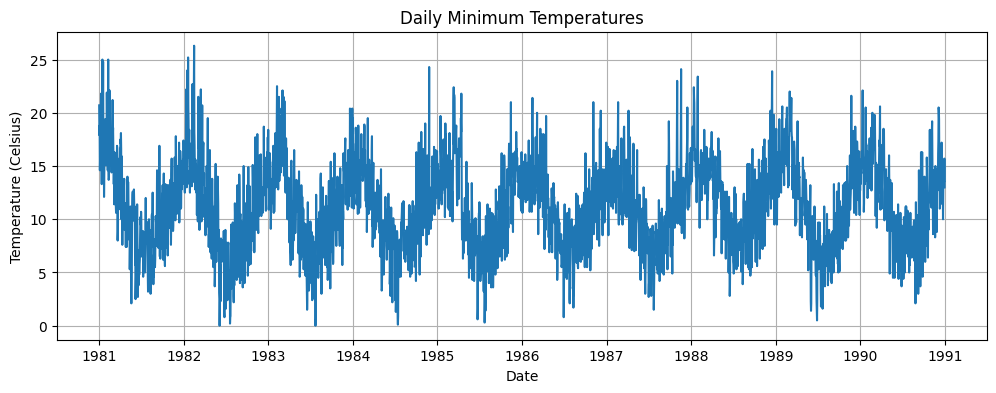

In [3]:
url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/daily-min-temperatures.csv'
df  = pd.read_csv(url, parse_dates=['Date'])

plt.figure(figsize=(12, 4))
plt.plot(df['Date'], df['Temp'])
plt.title('Daily Minimum Temperatures')
plt.xlabel('Date')
plt.ylabel('Temperature (Celsius)')
plt.grid(True)
plt.show()

In [4]:
scaler = MinMaxScaler()
temp_values     = df['Temp'].values.reshape(-1, 1)
temp_normalized = scaler.fit_transform(temp_values)

SEQ_LENGTH = 25

In [5]:
def create_many_to_one_sequences(data, seq_length):
    xs, ys = [], []
    for i in range(0, len(data) - seq_length, seq_length):
        xs.append(data[i : i + seq_length])          # 25 input steps
        ys.append(data[i + seq_length])               # 1 output step
    return np.array(xs), np.array(ys)


def create_many_to_many_sequences(data, seq_length):
    xs, ys = [], []
    for i in range(0, len(data) - seq_length, seq_length):
        xs.append(data[i     : i + seq_length])       # input:  t .. t+24
        ys.append(data[i + 1 : i + seq_length + 1])   # target: t+1 .. t+25
    return np.array(xs), np.array(ys)


class TimeSeriesDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
    def __len__(self):             return len(self.X)
    def __getitem__(self, idx):    return self.X[idx], self.y[idx]


def make_loaders(X, y, batch_size=32):
    train_size = int(len(X) * 0.8)
    val_size   = int(len(X) * 0.1)
    X_train, y_train = X[:train_size],                         y[:train_size]
    X_val,   y_val   = X[train_size:train_size+val_size],      y[train_size:train_size+val_size]
    X_test,  y_test  = X[train_size+val_size:],                y[train_size+val_size:]

    train_loader = DataLoader(TimeSeriesDataset(X_train, y_train), batch_size=batch_size, shuffle=True)
    val_loader   = DataLoader(TimeSeriesDataset(X_val,   y_val),   batch_size=batch_size, shuffle=False)
    test_loader  = DataLoader(TimeSeriesDataset(X_test,  y_test),  batch_size=batch_size, shuffle=False)
    return train_loader, val_loader, test_loader

## Build data loaders

In [6]:
# Many-to-one
X_m2o, y_m2o = create_many_to_one_sequences(temp_normalized, SEQ_LENGTH)
train_loader_m2o, val_loader_m2o, test_loader_m2o = make_loaders(X_m2o, y_m2o)

# Many-to-many
X_m2m, y_m2m = create_many_to_many_sequences(temp_normalized, SEQ_LENGTH)
train_loader_m2m, val_loader_m2m, test_loader_m2m = make_loaders(X_m2m, y_m2m)

print('Many-to-one  — X shape:', X_m2o.shape, ' y shape:', y_m2o.shape)
print('Many-to-many — X shape:', X_m2m.shape, ' y shape:', y_m2m.shape)

Many-to-one  — X shape: (145, 25, 1)  y shape: (145, 1)
Many-to-many — X shape: (145, 25, 1)  y shape: (145, 25, 1)


## Models — same structure as Lab 3.2.1

In [7]:
# Many-to-one: only predict the last RNN output
class RNNManyToOne(nn.Module):
    def __init__(self, input_size=1, hidden_size=32, num_layers=1):
        super().__init__()
        self.rnn = nn.RNN(input_size, hidden_size, num_layers, batch_first=True)
        self.fc  = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.rnn(x)          # out: (batch, seq_len, hidden)
        out    = self.fc(out[:, -1, :])  # only the last time step
        return out


# Many-to-many: apply the linear layer at every time step
class RNNManyToMany(nn.Module):
    def __init__(self, input_size=1, hidden_size=32, num_layers=1):
        super().__init__()
        self.rnn = nn.RNN(input_size, hidden_size, num_layers, batch_first=True)
        self.fc  = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.rnn(x)          # out: (batch, seq_len, hidden)
        out    = self.fc(out)         # all time steps → (batch, seq_len, 1)
        return out


print('Many-to-one model:')
print(RNNManyToOne())
print('\nMany-to-many model:')
print(RNNManyToMany())

Many-to-one model:
RNNManyToOne(
  (rnn): RNN(1, 32, batch_first=True)
  (fc): Linear(in_features=32, out_features=1, bias=True)
)

Many-to-many model:
RNNManyToMany(
  (rnn): RNN(1, 32, batch_first=True)
  (fc): Linear(in_features=32, out_features=1, bias=True)
)


## Training loop — same as Lab 3.2.1

In [8]:
def train_model(model, train_loader, val_loader, num_epochs=100, lr=0.001):
    model     = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    history   = {'train_loss': [], 'val_loss': []}

    for epoch in range(num_epochs):
        # -- train --
        model.train()
        train_loss = 0.0
        for batch_x, batch_y in train_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            preds = model(batch_x)
            loss  = criterion(preds, batch_y)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
        train_loss /= len(train_loader)

        # -- validate --
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for batch_x, batch_y in val_loader:
                batch_x, batch_y = batch_x.to(device), batch_y.to(device)
                preds    = model(batch_x)
                val_loss += criterion(preds, batch_y).item()
        val_loss /= len(val_loader)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)

        if (epoch + 1) % 20 == 0:
            print(f'Epoch {epoch+1}/{num_epochs}  train_loss {train_loss:.4f}  val_loss {val_loss:.4f}')

    return model, history

## Train both models

In [9]:
NUM_EPOCHS = 100

print('=== Training Many-to-One ===')
model_m2o, hist_m2o = train_model(
    RNNManyToOne(), train_loader_m2o, val_loader_m2o, num_epochs=NUM_EPOCHS)

print('\n=== Training Many-to-Many ===')
model_m2m, hist_m2m = train_model(
    RNNManyToMany(), train_loader_m2m, val_loader_m2m, num_epochs=NUM_EPOCHS)

=== Training Many-to-One ===
Epoch 20/100  train_loss 0.0169  val_loss 0.0092
Epoch 40/100  train_loss 0.0114  val_loss 0.0090
Epoch 60/100  train_loss 0.0111  val_loss 0.0077
Epoch 80/100  train_loss 0.0115  val_loss 0.0073
Epoch 100/100  train_loss 0.0120  val_loss 0.0068

=== Training Many-to-Many ===
Epoch 20/100  train_loss 0.0142  val_loss 0.0139
Epoch 40/100  train_loss 0.0106  val_loss 0.0091
Epoch 60/100  train_loss 0.0099  val_loss 0.0086
Epoch 80/100  train_loss 0.0096  val_loss 0.0084
Epoch 100/100  train_loss 0.0094  val_loss 0.0081


## Plot training and validation losses

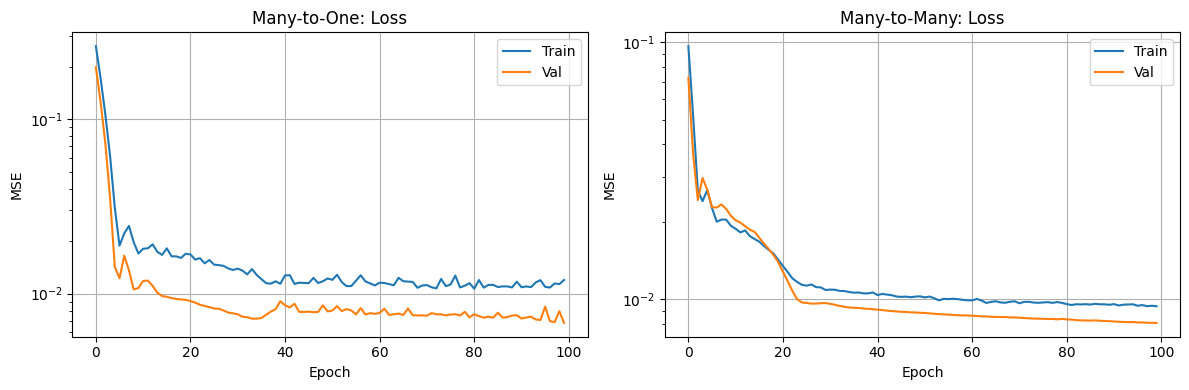

In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(hist_m2o['train_loss'], label='Train')
ax1.plot(hist_m2o['val_loss'],   label='Val')
ax1.set_title('Many-to-One: Loss')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('MSE')
ax1.set_yscale('log'); ax1.legend(); ax1.grid(True)

ax2.plot(hist_m2m['train_loss'], label='Train')
ax2.plot(hist_m2m['val_loss'],   label='Val')
ax2.set_title('Many-to-Many: Loss')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('MSE')
ax2.set_yscale('log'); ax2.legend(); ax2.grid(True)

plt.tight_layout()
plt.show()

## Evaluate on test set

In [11]:
criterion = nn.MSELoss()

def test_model(model, test_loader):
    model.eval()
    test_loss = 0.0
    all_inputs, all_preds, all_actuals = [], [], []
    with torch.no_grad():
        for batch_x, batch_y in test_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            preds     = model(batch_x)
            test_loss += criterion(preds, batch_y).item()
            all_inputs.append(batch_x.cpu().numpy())
            all_preds.append(preds.cpu().numpy())
            all_actuals.append(batch_y.cpu().numpy())
    test_loss /= len(test_loader)
    return test_loss, np.concatenate(all_inputs), np.concatenate(all_preds), np.concatenate(all_actuals)

loss_m2o, inputs_m2o, preds_m2o, actuals_m2o = test_model(model_m2o, test_loader_m2o)
loss_m2m, inputs_m2m, preds_m2m, actuals_m2m = test_model(model_m2m, test_loader_m2m)

print(f'Many-to-One  test MSE: {loss_m2o:.4f}')
print(f'Many-to-Many test MSE: {loss_m2m:.4f}')

Many-to-One  test MSE: 0.0151
Many-to-Many test MSE: 0.0083


## Visualize example sequences and predictions

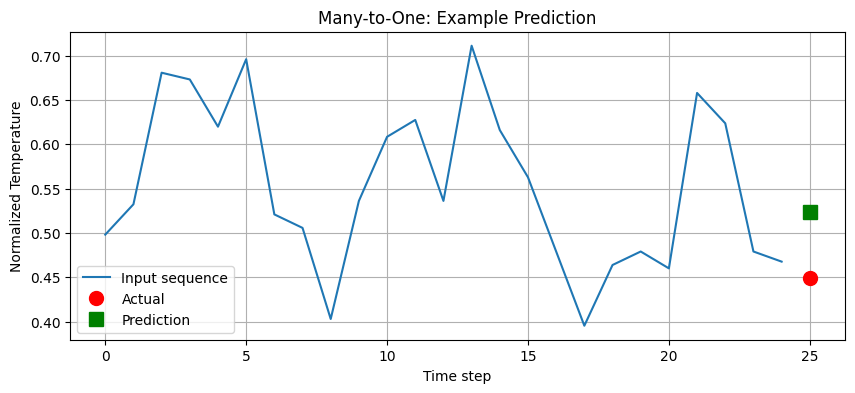

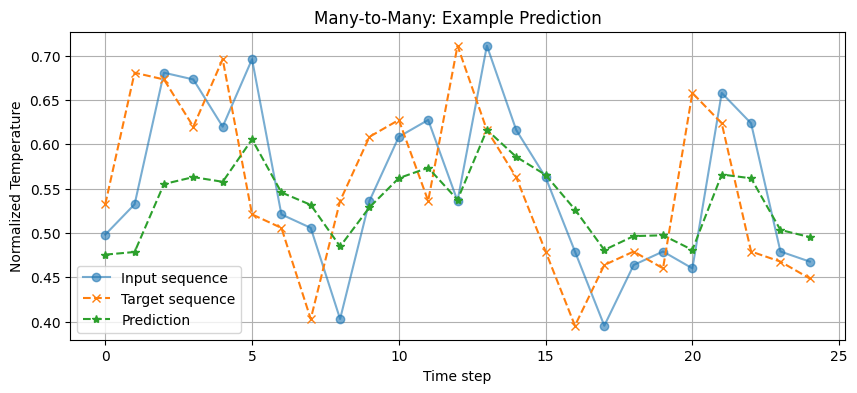

In [12]:
# --- Many-to-One example ---
idx = 0
plt.figure(figsize=(10, 4))
plt.plot(inputs_m2o[idx],  label='Input sequence')
plt.plot(SEQ_LENGTH, actuals_m2o[idx], 'ro', markersize=10, label='Actual')
plt.plot(SEQ_LENGTH, preds_m2o[idx],   'gs', markersize=10, label='Prediction')
plt.title('Many-to-One: Example Prediction')
plt.xlabel('Time step'); plt.ylabel('Normalized Temperature')
plt.legend(); plt.grid(True)
plt.show()

# --- Many-to-Many example ---
idx = 0
plt.figure(figsize=(10, 4))
plt.plot(inputs_m2m[idx],            label='Input sequence', marker='o', alpha=0.6)
plt.plot(actuals_m2m[idx].flatten(), label='Target sequence', marker='x', linestyle='--')
plt.plot(preds_m2m[idx].flatten(),   label='Prediction',     marker='*', linestyle='--')
plt.title('Many-to-Many: Example Prediction')
plt.xlabel('Time step'); plt.ylabel('Normalized Temperature')
plt.legend(); plt.grid(True)
plt.show()

---
# Task 3.4.2 — Row-by-Row RNN for MNIST

Each MNIST image (28×28) is treated as a **sequence of 28 rows**, each row being a 28-dimensional input vector.

## Load MNIST efficiently using TensorDataset

In [13]:
# Download MNIST
transform = transforms.Compose([transforms.ToTensor()])
mnist_train_raw = datasets.MNIST(root='./data', train=True,  download=True, transform=transform)
mnist_test_raw  = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

# Shape: (N, 28, 28) — each image is a sequence of 28 rows
X_train_mnist = mnist_train_raw.data.float() / 255.0   # (60000, 28, 28)
y_train_mnist = mnist_train_raw.targets                 # (60000,)
X_test_mnist  = mnist_test_raw.data.float()  / 255.0   # (10000, 28, 28)
y_test_mnist  = mnist_test_raw.targets                  # (10000,)

# Move to device
X_train_mnist = X_train_mnist.to(device)
y_train_mnist = y_train_mnist.to(device)
X_test_mnist  = X_test_mnist.to(device)
y_test_mnist  = y_test_mnist.to(device)

# Wrap in TensorDataset
train_dataset_mnist = TensorDataset(X_train_mnist, y_train_mnist)
test_dataset_mnist  = TensorDataset(X_test_mnist,  y_test_mnist)

BATCH_SIZE_MNIST = 512
train_loader_mnist = DataLoader(train_dataset_mnist, batch_size=BATCH_SIZE_MNIST, shuffle=True)
test_loader_mnist  = DataLoader(test_dataset_mnist,  batch_size=BATCH_SIZE_MNIST, shuffle=False)

print('Train set:', X_train_mnist.shape)
print('Test set: ', X_test_mnist.shape)
print('Each sample shape (rows as time steps): (28, 28)')

100%|██████████| 9.91M/9.91M [00:01<00:00, 5.08MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 135kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.27MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 10.5MB/s]


Train set: torch.Size([60000, 28, 28])
Test set:  torch.Size([10000, 28, 28])
Each sample shape (rows as time steps): (28, 28)


## Build the RNN — many-to-one with hidden_size=8, num_layers=2

In [14]:
class MNISTRowRNN(nn.Module):
    def __init__(self, input_size=28, hidden_size=8, num_layers=2, num_classes=10):
        super().__init__()
        # input_size=28 because each row of the image has 28 pixels
        # hidden_size=8 and num_layers=2 as required by the task
        self.rnn = nn.RNN(input_size, hidden_size, num_layers, batch_first=True)
        self.fc  = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        # x shape coming in: (batch, 28, 28)
        # the RNN sees 28 time steps, each of size 28
        out, _ = self.rnn(x)           # out: (batch, 28, 8)
        out    = self.fc(out[:, -1, :])  # only last row → (batch, 10)
        return out

mnist_model = MNISTRowRNN()
print(mnist_model)

MNISTRowRNN(
  (rnn): RNN(28, 8, num_layers=2, batch_first=True)
  (fc): Linear(in_features=8, out_features=10, bias=True)
)


## Print name, shape, and number of parameters for each layer

In [15]:
print(f'{'Layer name':<30} {'Shape':<25} {'# Parameters'}')
print('-' * 65)
total = 0
for name, param in mnist_model.named_parameters():
    n = param.numel()
    total += n
    print(f'{name:<30} {str(list(param.shape)):<25} {n}')
print('-' * 65)
print(f'Total parameters: {total}')

Layer name                     Shape                     # Parameters
-----------------------------------------------------------------
rnn.weight_ih_l0               [8, 28]                   224
rnn.weight_hh_l0               [8, 8]                    64
rnn.bias_ih_l0                 [8]                       8
rnn.bias_hh_l0                 [8]                       8
rnn.weight_ih_l1               [8, 8]                    64
rnn.weight_hh_l1               [8, 8]                    64
rnn.bias_ih_l1                 [8]                       8
rnn.bias_hh_l1                 [8]                       8
fc.weight                      [10, 8]                   80
fc.bias                        [10]                      10
-----------------------------------------------------------------
Total parameters: 538


## Train for 30 epochs

In [16]:
import time

mnist_model = mnist_model.to(device)
optimizer   = torch.optim.Adam(mnist_model.parameters(), lr=0.001)
criterion   = nn.CrossEntropyLoss()

mnist_history = {'train_loss': [], 'val_loss': [], 'val_acc': []}

start = time.time()

for epoch in range(30):
    # -- train --
    mnist_model.train()
    train_loss = 0.0
    for batch_x, batch_y in train_loader_mnist:
        # batch_x is already on device, shape: (batch, 28, 28)
        preds = mnist_model(batch_x)
        loss  = criterion(preds, batch_y)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    train_loss /= len(train_loader_mnist)

    # -- evaluate on test set --
    mnist_model.eval()
    val_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for batch_x, batch_y in test_loader_mnist:
            preds     = mnist_model(batch_x)
            val_loss += criterion(preds, batch_y).item()
            correct  += (preds.argmax(dim=1) == batch_y).sum().item()
            total    += batch_y.size(0)
    val_loss /= len(test_loader_mnist)
    val_acc   = correct / total

    mnist_history['train_loss'].append(train_loss)
    mnist_history['val_loss'].append(val_loss)
    mnist_history['val_acc'].append(val_acc)

    print(f'Epoch {epoch+1:02d}/30  train_loss {train_loss:.4f}  '
          f'val_loss {val_loss:.4f}  val_acc {val_acc:.4f}')

elapsed = time.time() - start
print(f'\nTotal training time: {elapsed:.1f}s')

Epoch 01/30  train_loss 2.2093  val_loss 2.0513  val_acc 0.2335
Epoch 02/30  train_loss 1.9125  val_loss 1.8130  val_acc 0.3447
Epoch 03/30  train_loss 1.7519  val_loss 1.7185  val_acc 0.3719
Epoch 04/30  train_loss 1.6507  val_loss 1.5846  val_acc 0.4457
Epoch 05/30  train_loss 1.5004  val_loss 1.4455  val_acc 0.4656
Epoch 06/30  train_loss 1.4061  val_loss 1.3744  val_acc 0.4874
Epoch 07/30  train_loss 1.3466  val_loss 1.3236  val_acc 0.5202
Epoch 08/30  train_loss 1.2973  val_loss 1.2744  val_acc 0.5495
Epoch 09/30  train_loss 1.2549  val_loss 1.2422  val_acc 0.5759
Epoch 10/30  train_loss 1.2234  val_loss 1.2090  val_acc 0.5843
Epoch 11/30  train_loss 1.1939  val_loss 1.1896  val_acc 0.5881
Epoch 12/30  train_loss 1.1711  val_loss 1.1652  val_acc 0.5966
Epoch 13/30  train_loss 1.1463  val_loss 1.1418  val_acc 0.6030
Epoch 14/30  train_loss 1.1219  val_loss 1.1141  val_acc 0.6096
Epoch 15/30  train_loss 1.0987  val_loss 1.0993  val_acc 0.6160
Epoch 16/30  train_loss 1.0767  val_loss

## Plot training and validation losses

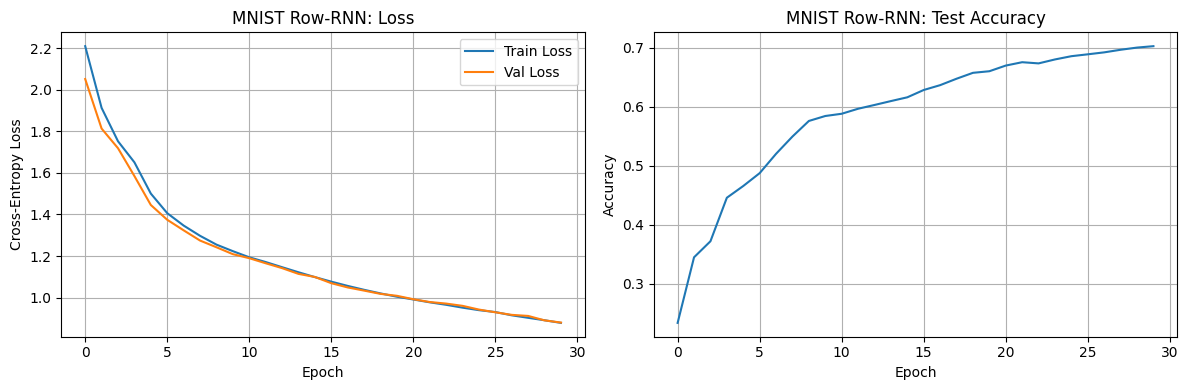

Final test accuracy: 70.27%


In [17]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(mnist_history['train_loss'], label='Train Loss')
ax1.plot(mnist_history['val_loss'],   label='Val Loss')
ax1.set_title('MNIST Row-RNN: Loss')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Cross-Entropy Loss')
ax1.legend(); ax1.grid(True)

ax2.plot(mnist_history['val_acc'])
ax2.set_title('MNIST Row-RNN: Test Accuracy')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy')
ax2.grid(True)

plt.tight_layout()
plt.show()

print(f'Final test accuracy: {mnist_history["val_acc"][-1]*100:.2f}%')